# 05 — Carrier × Merchant Cross Analysis (Block D)
## REVER Logistics Cost & Revenue Analysis — 2025

Answers Block D questions: margin heatmap carrier × merchant, cost efficiency per kg, and custom costs crossed.

**Requires:** `01_preparacion.ipynb` to have been run first.

In [1]:
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
warnings.filterwarnings("ignore")

PROCESSED = Path("../processed")
PALETTE = {
    "primary": "#2C5F8A", "positive": "#2A9D8F", "negative": "#E63946",
    "neutral": "#ADB5BD", "accent": "#F4A261", "bg": "#FFFFFF", "grid": "#F0F0F0",
}
CARRIER_COLORS = {
    "Correos": "#F4A261", "Correos Express": "#E63946",
    "UPS": "#8B5E3C", "GLS": "#2A9D8F", "BRT": "#457B9D",
}
plt.rcParams.update({
    "figure.facecolor": PALETTE["bg"], "axes.facecolor": PALETTE["bg"],
    "axes.grid": True, "grid.color": PALETTE["grid"], "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.spines.left": True, "axes.spines.bottom": True,
    "axes.edgecolor": "#CCCCCC", "font.family": "sans-serif", "font.size": 11,
    "axes.titlesize": 14, "axes.titleweight": "bold", "axes.labelsize": 11,
    "xtick.labelsize": 10, "ytick.labelsize": 10,
    "legend.frameon": False, "legend.fontsize": 10,
    "figure.dpi": 110, "figure.figsize": (14, 5),
})
FIG_W, FIG_H = 14, 5

merged  = pd.read_parquet(PROCESSED / "merged.parquet")
matched = merged.dropna(subset=["rever_revenue_net"]).copy()

# Limit to top 30 merchants by volume to keep heatmaps readable
top_merchants = (
    matched.groupby("stripe_cust_id")["tracking_id"].count()
    .sort_values(ascending=False).head(30).index.tolist()
)
matched_top = matched[matched["stripe_cust_id"].isin(top_merchants)].copy()
print(f"matched: {len(matched):,} rows | top 30 merchants subset: {len(matched_top):,} rows")

matched: 244,149 rows | top 30 merchants subset: 120,702 rows


---
## D1 — Margin heatmap: carrier × merchant (top 30)

Each cell shows avg margin per shipment for that carrier + merchant combination.
Red = REVER loses money on that combination. Blue = positive margin. Grey = no shipments.

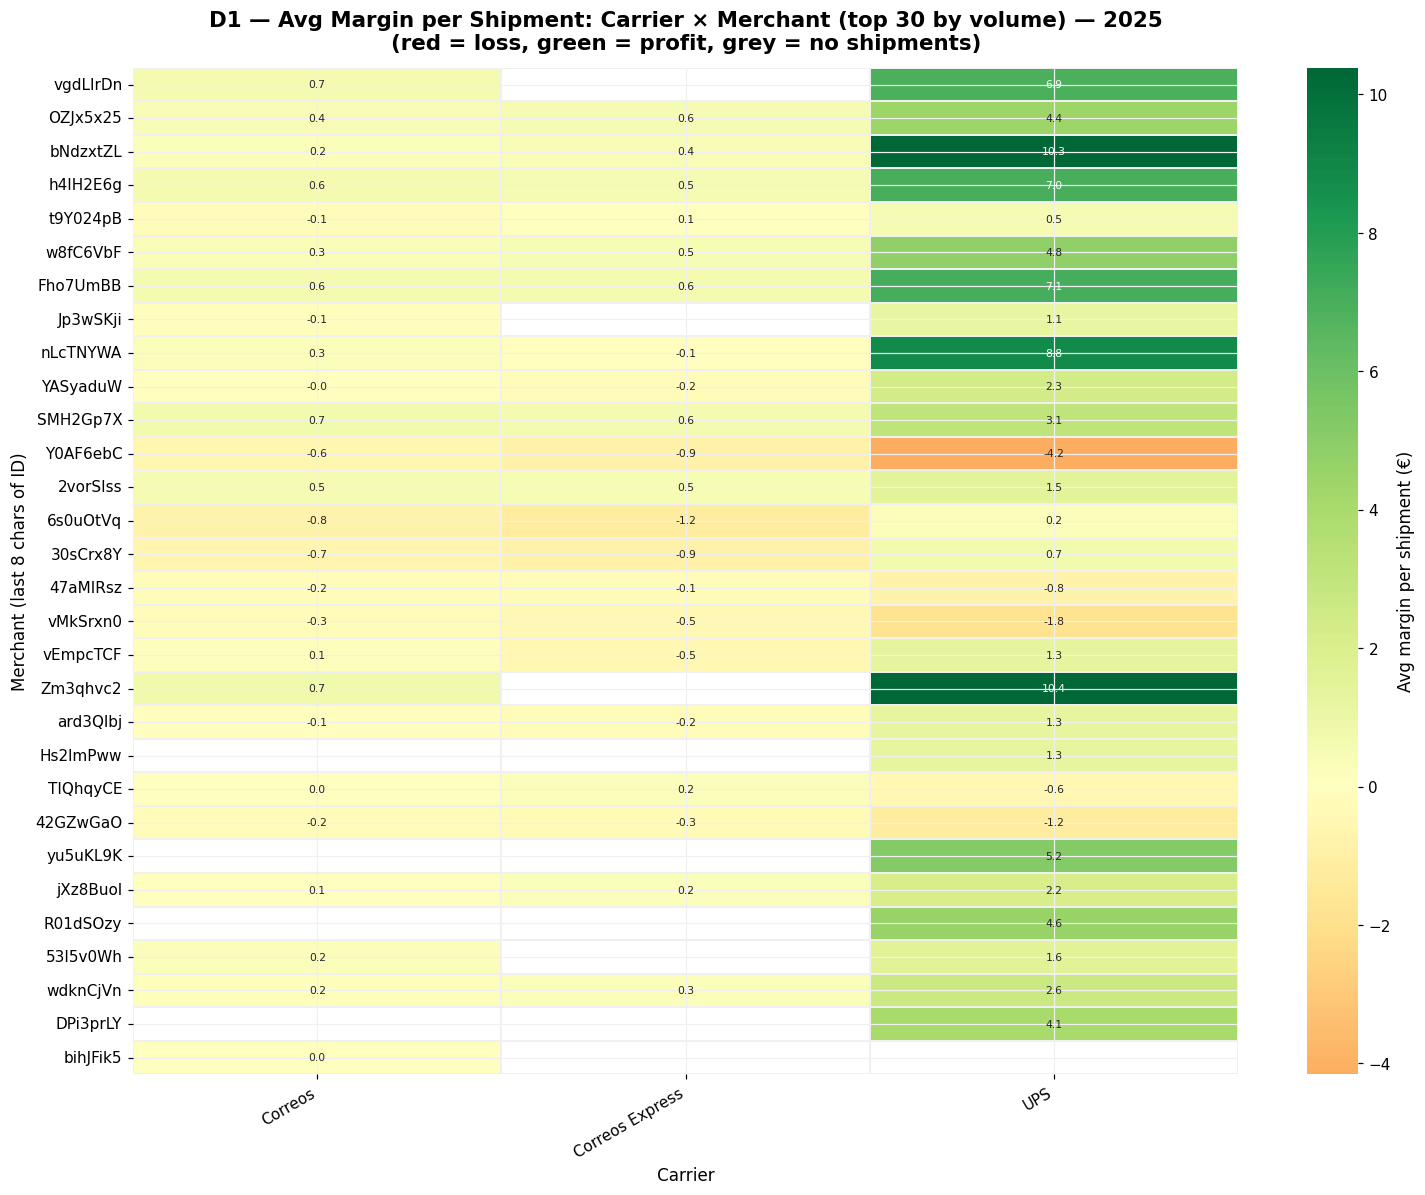

In [2]:
# ── D1: Margin heatmap carrier × merchant (top 30) ───────────────────────────
heatmap_data = (
    matched_top.groupby(["stripe_cust_id", "carrier"])["margin_eur"]
    .mean()
    .reset_index()
    .pivot(index="stripe_cust_id", columns="carrier", values="margin_eur")
)
# Shorten merchant IDs for readability
heatmap_data.index = heatmap_data.index.str[-8:]

fig, ax = plt.subplots(figsize=(FIG_W, FIG_H + 6))
sns.heatmap(
    heatmap_data,
    ax=ax,
    cmap="RdYlGn",
    center=0,
    annot=True,
    fmt=".1f",
    annot_kws={"size": 7},
    linewidths=0.3,
    linecolor=PALETTE["grid"],
    cbar_kws={"label": "Avg margin per shipment (€)"},
)
ax.set_xlabel("Carrier")
ax.set_ylabel("Merchant (last 8 chars of ID)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
ax.set_title("D1 — Avg Margin per Shipment: Carrier × Merchant (top 30 by volume) — 2025\n(red = loss, green = profit, grey = no shipments)", pad=12)
plt.tight_layout()
plt.show()

---
## D2 — Cost efficiency: €/kg by carrier × merchant

Which carrier delivers the best cost-per-kg for each merchant?
Low €/kg = more efficient for heavy shipments. Guides carrier assignment decisions.

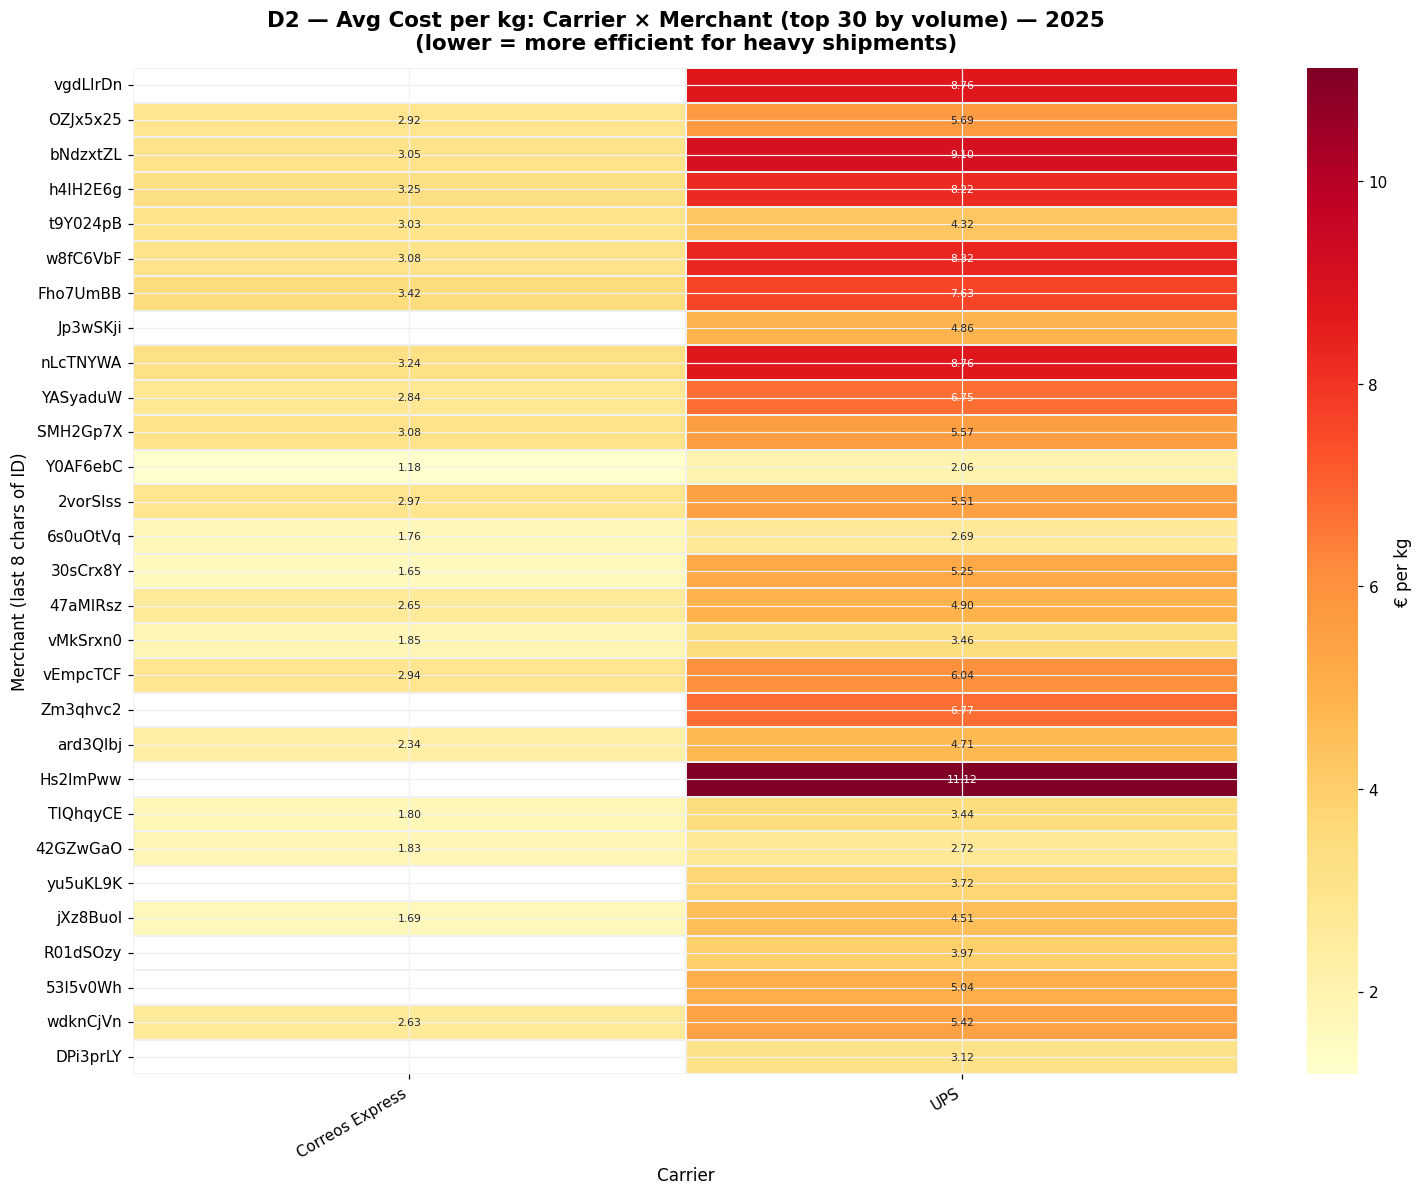

In [3]:
# ── D2: Cost efficiency (€/kg) by carrier × merchant (top 30) ────────────────
weight_data = matched_top.dropna(subset=["billed_weight_kg"]).copy()
weight_data = weight_data[weight_data["billed_weight_kg"] > 0]
weight_data["cost_per_kg"] = weight_data["carrier_cost_net"] / weight_data["billed_weight_kg"]

if len(weight_data) == 0:
    print("No billed_weight_kg data available for D2.")
else:
    d2 = (
        weight_data.groupby(["stripe_cust_id", "carrier"])["cost_per_kg"]
        .mean()
        .reset_index()
        .pivot(index="stripe_cust_id", columns="carrier", values="cost_per_kg")
    )
    d2.index = d2.index.str[-8:]

    fig, ax = plt.subplots(figsize=(FIG_W, FIG_H + 6))
    sns.heatmap(
        d2, ax=ax, cmap="YlOrRd", annot=True, fmt=".2f",
        annot_kws={"size": 7},
        linewidths=0.3, linecolor=PALETTE["grid"],
        cbar_kws={"label": "€ per kg"},
    )
    ax.set_xlabel("Carrier")
    ax.set_ylabel("Merchant (last 8 chars of ID)")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
    ax.set_title("D2 — Avg Cost per kg: Carrier × Merchant (top 30 by volume) — 2025\n(lower = more efficient for heavy shipments)", pad=12)
    plt.tight_layout()
    plt.show()

---
## D3 — Custom cost heatmap: carrier × merchant

`rever_custom_cost` is the extra cost REVER charges beyond the base logistic cost.
High custom cost in a specific carrier × merchant combination may indicate special agreements or systematic surcharges.

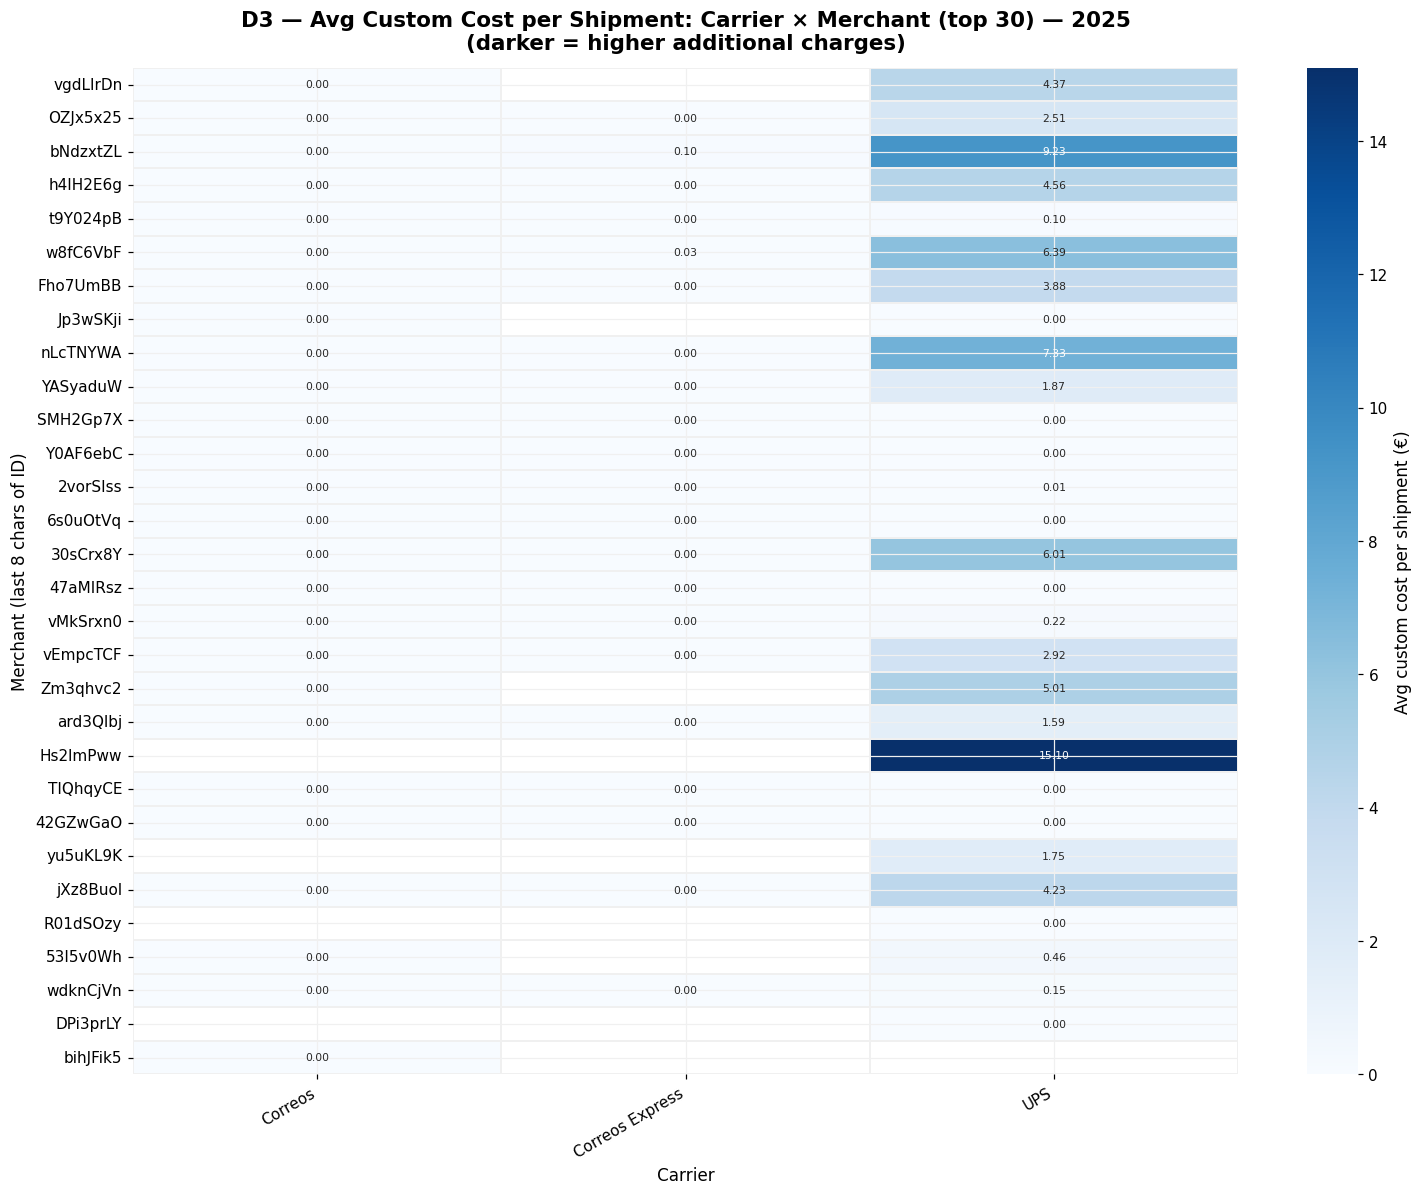

In [4]:
# ── D3: Custom cost heatmap carrier × merchant (top 30) ──────────────────────
if "rever_custom_cost" not in matched_top.columns:
    print("rever_custom_cost not available — skipping D3.")
else:
    d3 = (
        matched_top.groupby(["stripe_cust_id", "carrier"])["rever_custom_cost"]
        .mean()
        .reset_index()
        .pivot(index="stripe_cust_id", columns="carrier", values="rever_custom_cost")
    )
    d3.index = d3.index.str[-8:]

    fig, ax = plt.subplots(figsize=(FIG_W, FIG_H + 6))
    sns.heatmap(
        d3, ax=ax, cmap="Blues", annot=True, fmt=".2f",
        annot_kws={"size": 7},
        linewidths=0.3, linecolor=PALETTE["grid"],
        cbar_kws={"label": "Avg custom cost per shipment (€)"},
    )
    ax.set_xlabel("Carrier")
    ax.set_ylabel("Merchant (last 8 chars of ID)")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
    ax.set_title("D3 — Avg Custom Cost per Shipment: Carrier × Merchant (top 30) — 2025\n(darker = higher additional charges)", pad=12)
    plt.tight_layout()
    plt.show()